In [6]:
import numpy as np

# Set up matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

from astropy.io import fits

In [7]:
hdu_list = fits.open("data/Focus_r_2025-05-05T21-18-55.fits")
hdu_list.info()

Filename: data/Focus_r_2025-05-05T21-18-55.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (2048, 2048)   int16 (rescales to uint16)   


In [8]:
hdu_list[0].header

SIMPLE  =                    T / C# FITS: 05.05.2025 21:19:20                   
BITPIX  =                   16                                                  
NAXIS   =                    2 / Dimensionality                                 
NAXIS1  =                 2048                                                  
NAXIS2  =                 2048                                                  
PMLS    =                    F / prim minus lim switch activated                
PPLS    =                    F / prim plus lim switch activated                 
TRACKING=                    T / is mount tracking                              
COMFAULT=                    F / com fault between sitech and brush             
INIT    =                    T / is mount initialized                           
SLEWING =                    F / is mount slewing                               
LOOKEAST=                    F / is mount looking east (GEM)                    
SPLS    =                   

In [9]:
image_data = hdu_list[0].data

In [10]:
def display_limits(image):
    """Use robust limits so bright pixels do not wash out the whole frame."""
    finite_pixels = image[np.isfinite(image)]
    if finite_pixels.size == 0:
        return 0.0, 1.0

    vmin, vmax = np.percentile(finite_pixels, [1, 99.5])
    if np.isclose(vmin, vmax):
        vmin = float(np.min(finite_pixels))
        vmax = float(np.max(finite_pixels))

    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0

    return float(vmin), float(vmax)

In [11]:
vmin, vmax = display_limits(image_data)

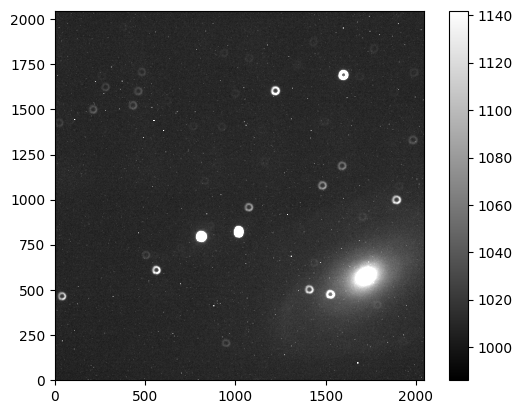

In [12]:
plt.imshow(image_data, cmap="gray", origin="lower",
                vmin=vmin,
                vmax=vmax)
plt.colorbar()

# To see more color maps
# http://wiki.scipy.org/Cookbook/Matplotlib/Show_colormaps

Full image shape: 2048 x 2048 pixels
Requested source center: x=1597, y=1687
Crop shape: (64, 64)
Crop x range: [1565, 1629)
Crop y range: [1655, 1719)


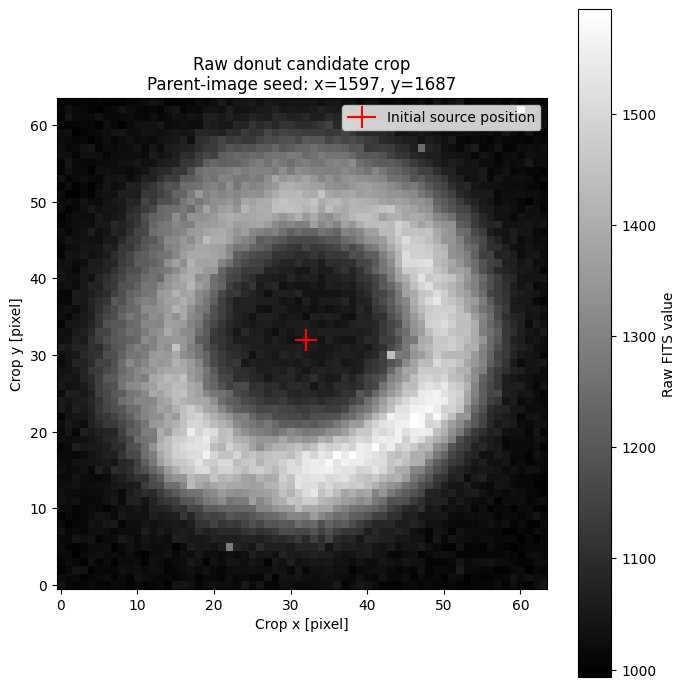

In [13]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval


# ------------------------------------------------------------
# File and candidate-source settings
# ------------------------------------------------------------
fits_path = Path("data/Focus_r_2025-05-05T21-18-55.fits")

# Approximate target center in Python / NumPy coordinates:
# x = column, y = row
x0 = 1597
y0 = 1687

crop_size = 64
half_size = crop_size // 2


# ------------------------------------------------------------
# Read the FITS image
# Astropy automatically handles FITS BSCALE / BZERO correctly.
# Do NOT add BZERO manually.
# ------------------------------------------------------------
with fits.open(fits_path) as hdul:
    data = np.asarray(hdul[0].data, dtype=np.float64)
    parent_header = hdul[0].header.copy()

if data.ndim != 2:
    raise ValueError(f"Expected a 2-D image, but received shape {data.shape}.")

height, width = data.shape

print(f"Full image shape: {width} x {height} pixels")
print(f"Requested source center: x={x0}, y={y0}")


# ------------------------------------------------------------
# Define crop bounds
# ------------------------------------------------------------
x_start = x0 - half_size
x_stop = x0 + half_size

y_start = y0 - half_size
y_stop = y0 + half_size

if x_start < 0 or y_start < 0 or x_stop > width or y_stop > height:
    raise ValueError(
        "The requested crop extends beyond the image boundary. "
        f"Crop bounds are x=[{x_start}, {x_stop}), "
        f"y=[{y_start}, {y_stop}), "
        f"but image dimensions are {width} x {height}."
    )


# ------------------------------------------------------------
# Crop raw detector values
# Do not background-subtract, clip, normalize, or resize here.
# ------------------------------------------------------------
crop_raw = data[y_start:y_stop, x_start:x_stop].copy()

print(f"Crop shape: {crop_raw.shape}")
print(f"Crop x range: [{x_start}, {x_stop})")
print(f"Crop y range: [{y_start}, {y_stop})")


# ------------------------------------------------------------
# Display only:
# ZScale changes visualization contrast, not actual pixel values.
# ------------------------------------------------------------
finite_pixels = crop_raw[np.isfinite(crop_raw)]

zscale = ZScaleInterval(contrast=0.25)
vmin, vmax = zscale.get_limits(finite_pixels)

fig, ax = plt.subplots(figsize=(7, 7))

image_plot = ax.imshow(
    crop_raw,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

ax.plot(
    half_size,
    half_size,
    marker="+",
    markersize=16,
    markeredgewidth=1.5,
    color="red",
    label="Initial source position"
)

ax.set_title(
    "Raw donut candidate crop\n"
    f"Parent-image seed: x={x0}, y={y0}"
)

ax.set_xlabel("Crop x [pixel]")
ax.set_ylabel("Crop y [pixel]")
ax.legend(loc="upper right")
plt.colorbar(image_plot, ax=ax, label="Raw FITS value")
plt.tight_layout()
plt.show()

In [14]:
# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
output_dir = Path("processed/crops")
output_dir.mkdir(parents=True, exist_ok=True)

crop_fits_path = output_dir / "donut_candidate_x1597_y1687_raw.fits"
metadata_path = output_dir / "donut_candidate_x1597_y1687_metadata.json"


# ------------------------------------------------------------
# Make a clean crop header.
# Do not copy the entire original header because WCS keywords
# such as CRPIX would need to be shifted after cropping.
# ------------------------------------------------------------
crop_header = fits.Header()

# Preserve selected observational metadata where available.
keys_to_copy = [
    "DATE-OBS",
    "EXPTIME",
    "FILTER",
    "FOCUS",
    "GAIN",
    "RDNOISE",
    "SEEING",
    "XBINNING",
    "YBINNING",
    "XPIXSZ",
    "YPIXSZ",
    "TELESCOP",
    "INSTRUME",
]

for key in keys_to_copy:
    if key in parent_header:
        crop_header[key] = parent_header[key]

crop_header["PARENT"] = (fits_path.name, "Original FITS image")
crop_header["SRCX0"] = (int(x0), "Source seed x in parent image, 0-based")
crop_header["SRCY0"] = (int(y0), "Source seed y in parent image, 0-based")
crop_header["XSTART"] = (int(x_start), "Crop start x in parent image")
crop_header["YSTART"] = (int(y_start), "Crop start y in parent image")
crop_header["CROPSIZE"] = (int(crop_size), "Square crop side in pixels")
crop_header["PROCSTAT"] = ("RAW_CROP", "No background subtraction or normalization")


# Save raw image values as float32.
fits.writeto(
    crop_fits_path,
    crop_raw.astype(np.float32),
    header=crop_header,
    overwrite=True
)


# Save matching metadata as JSON for later processing.
metadata = {
    "parent_fits": str(fits_path),
    "crop_fits": str(crop_fits_path),
    "source_seed_coordinate_parent_0_based": {
        "x": int(x0),
        "y": int(y0)
    },
    "crop_bounds_parent_0_based": {
        "x_start": int(x_start),
        "x_stop_exclusive": int(x_stop),
        "y_start": int(y_start),
        "y_stop_exclusive": int(y_stop)
    },
    "crop_size_pixels": int(crop_size),
    "processing_state": "raw crop only",
    "notes": [
        "No background subtraction applied.",
        "No flux normalization applied.",
        "No resampling or rotation applied.",
        "Nearby sources have not yet been masked.",
        "The donut center has not yet been refined."
    ]
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Saved raw crop to: {crop_fits_path}")
print(f"Saved metadata to: {metadata_path}")

Saved raw crop to: processed/crops/donut_candidate_x1597_y1687_raw.fits
Saved metadata to: processed/crops/donut_candidate_x1597_y1687_metadata.json


In [15]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats


# ------------------------------------------------------------
# 1. Load the RAW 64x64 crop
# ------------------------------------------------------------
crop_path = Path("processed/crops/donut_candidate_x1597_y1687_raw.fits")

raw = fits.getdata(crop_path).astype(np.float64)

if raw.shape != (64, 64):
    raise ValueError(
        f"Expected a 64x64 crop, but got {raw.shape}. "
        "Keep the DONUT input at its original crop size."
    )

ny, nx = raw.shape
yy, xx = np.indices(raw.shape)

# Approximate initial center: middle of the crop.
# This only initializes the calculation; the model will later fit dx, dy.
x_seed = (nx - 1) / 2
y_seed = (ny - 1) / 2

r_seed = np.hypot(xx - x_seed, yy - y_seed)


# ------------------------------------------------------------
# 2. Estimate local background
#
# The ring radius is roughly ~17 pixels, so use pixels well
# outside the donut: 24 <= r <= 30 pixels.
# ------------------------------------------------------------
background_mask = (
    np.isfinite(raw)
    & (r_seed >= 24.0)
    & (r_seed <= 30.0)
)

if background_mask.sum() < 50:
    raise RuntimeError("Too few pixels available for background estimation.")

_, background_adu, background_std_adu = sigma_clipped_stats(
    raw[background_mask],
    sigma=3.0,
    maxiters=5
)

signal = raw - background_adu


# ------------------------------------------------------------
# 3. First centroid estimate
#
# For the moment calculation only, negative values are clipped.
# This prevents background noise from pulling the centroid.
# ------------------------------------------------------------
moment_radius = 25.0

moment_mask = (
    np.isfinite(signal)
    & (r_seed <= moment_radius)
)

weights = np.clip(signal, 0.0, None) * moment_mask
flux_for_moments = weights.sum()

if flux_for_moments <= 0:
    raise RuntimeError(
        "No positive signal was found. Check the crop position "
        "or the background-annulus radii."
    )

x_c = (xx * weights).sum() / flux_for_moments
y_c = (yy * weights).sum() / flux_for_moments


# ------------------------------------------------------------
# 4. Re-estimate background around the measured center
# ------------------------------------------------------------
r = np.hypot(xx - x_c, yy - y_c)

background_mask = (
    np.isfinite(raw)
    & (r >= 24.0)
    & (r <= 30.0)
)

_, background_adu, background_std_adu = sigma_clipped_stats(
    raw[background_mask],
    sigma=3.0,
    maxiters=5
)

signal = raw - background_adu


# ------------------------------------------------------------
# 5. Create the fitting mask
#
# We fit only the source region + a little surrounding margin.
# Outer pixels and possible faint edge contamination are ignored.
# ------------------------------------------------------------
fit_radius = 25.0

fit_mask = (
    np.isfinite(signal)
    & (r <= fit_radius)
)

# For this first proof-of-concept version:
# use only positive source signal and normalize total valid flux to 1.
#
# Later, in the noise-aware version, we will keep the signed residuals
# and use a variance model from Eq. (A4).
fit_signal = np.where(fit_mask, np.clip(signal, 0.0, None), 0.0)

total_flux = fit_signal.sum()

if total_flux <= 0:
    raise RuntimeError("Normalized flux is zero. Check the crop and mask.")

obs_norm = fit_signal / total_flux


# ------------------------------------------------------------
# 6. Equation (4): second moments
# ------------------------------------------------------------
Mx = (((xx - x_c)**2) * obs_norm).sum()
My = (((yy - y_c)**2) * obs_norm).sum()
Mxy = (((xx - x_c) * (yy - y_c)) * obs_norm).sum()


# ------------------------------------------------------------
# 7. Equation (5), still in PIXEL units
#
# We do not yet know the telescope plate scale p [arcsec/pixel],
# so these are image-space forms of A4, A5, A6.
# ------------------------------------------------------------
A4_pix = np.sqrt((Mx + My) / 2.0)
A5_pix = Mxy * (Mx * My)**(-0.25)
A6_pix = 0.5 * (Mx - My) * (Mx * My)**(-0.25)


# ------------------------------------------------------------
# 8. Print the first DONUT observables
# ------------------------------------------------------------
print("----- DONUT crop preparation -----")
print(f"Crop shape                    : {raw.shape}")
print(f"Local background              : {background_adu:.3f} ADU")
print(f"Background rms                : {background_std_adu:.3f} ADU")
print()
print(f"Initial donut center x_c      : {x_c:.3f} pixels")
print(f"Initial donut center y_c      : {y_c:.3f} pixels")
print()
print("Equation (4): second moments")
print(f"Mx                             : {Mx:.6f} pixel^2")
print(f"My                             : {My:.6f} pixel^2")
print(f"Mxy                            : {Mxy:.6f} pixel^2")
print()
print("Equation (5): shape observables in pixel units")
print(f"A4_pix  (donut size)          : {A4_pix:.6f} pixels")
print(f"A5_pix  (45-degree astig.)    : {A5_pix:.6f} pixels")
print(f"A6_pix  (0/90-degree astig.)  : {A6_pix:.6f} pixels")
print()
print(f"Normalized valid flux         : {obs_norm[fit_mask].sum():.8f}")
print(f"Pixels used in fitting        : {fit_mask.sum()} / {fit_mask.size}")

----- DONUT crop preparation -----
Crop shape                    : (64, 64)
Local background              : 1106.000 ADU
Background rms                : 85.361 ADU

Initial donut center x_c      : 32.888 pixels
Initial donut center y_c      : 30.267 pixels

Equation (4): second moments
Mx                             : 177.334911 pixel^2
My                             : 173.769501 pixel^2
Mxy                            : 13.398554 pixel^2

Equation (5): shape observables in pixel units
A4_pix  (donut size)          : 13.249612 pixels
A5_pix  (45-degree astig.)    : 1.011267 pixels
A6_pix  (0/90-degree astig.)  : 0.134551 pixels

Normalized valid flux         : 1.00000000
Pixels used in fitting        : 1964 / 4096


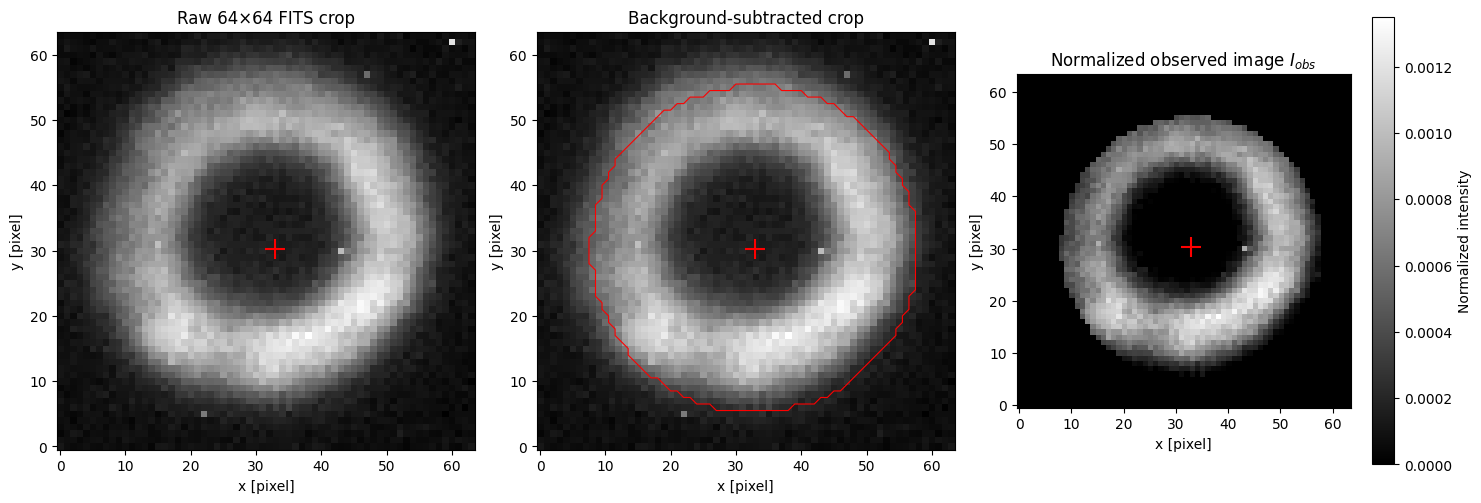

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Raw crop: display only
ax[0].imshow(raw, origin="lower", cmap="gray")
ax[0].plot(x_c, y_c, "r+", markersize=14, markeredgewidth=1.5)
ax[0].set_title("Raw 64×64 FITS crop")
ax[0].set_xlabel("x [pixel]")
ax[0].set_ylabel("y [pixel]")

# Background-subtracted signal
ax[1].imshow(signal, origin="lower", cmap="gray")
ax[1].plot(x_c, y_c, "r+", markersize=14, markeredgewidth=1.5)
ax[1].contour(fit_mask.astype(int), levels=[0.5], colors="red", linewidths=0.8)
ax[1].set_title("Background-subtracted crop")
ax[1].set_xlabel("x [pixel]")
ax[1].set_ylabel("y [pixel]")

# The actual image given to the DONUT fitter
im = ax[2].imshow(obs_norm, origin="lower", cmap="gray")
ax[2].plot(x_c, y_c, "r+", markersize=14, markeredgewidth=1.5)
ax[2].set_title("Normalized observed image $I_{obs}$")
ax[2].set_xlabel("x [pixel]")
ax[2].set_ylabel("y [pixel]")
plt.colorbar(im, ax=ax[2], label="Normalized intensity")

plt.tight_layout()
plt.show()

In [17]:
# ------------------------------------------------------------
# 12. Prototype inverse DONUT iteration: Eq. (A1)-Eq. (A6)
# ------------------------------------------------------------
# This cell assumes the preprocessing cell above has already created:
# raw, signal, obs_norm, fit_mask, x_c, y_c, A4_pix, A5_pix, A6_pix.
#
# Important unit warning:
# a4, a5, and a6 below are uncalibrated phase-amplitude model units.
# They are NOT micrometre rms wavefront coefficients until telescope
# diameter, wavelength, plate scale, focus geometry, and sign convention
# are calibrated.

from dataclasses import asdict, dataclass
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter, shift as nd_shift, zoom


required_inputs = [
    "obs_norm", "fit_mask", "x_c", "y_c", "A4_pix", "A5_pix", "A6_pix"
]
missing_inputs = [name for name in required_inputs if name not in globals()]
if missing_inputs:
    raise RuntimeError(
        "Run the crop/preprocessing cells before this inverse fit cell. "
        f"Missing variables: {missing_inputs}"
    )


# ------------------------------------------------------------
# Step 1. Parameter object and configuration
# ------------------------------------------------------------
@dataclass
class DonutParameters:
    seeing_fwhm_px: float
    dx_px: float
    dy_px: float
    a4: float
    a5: float
    a6: float


parameter_names = list(DonutParameters.__annotations__.keys())

inverse_config = {
    "fft_grid_size": 256,
    "detector_shape": tuple(obs_norm.shape),
    "central_obscuration_ratio": 0.24,  # placeholder assumption, not verified
    "image_plane_window_fft_px": 64,    # uncalibrated FFT-to-detector scale
    "max_iterations": 20,
    "damping": 0.7,
    "svd_rcond": 0.02,
    "min_relative_improvement": 1.0e-4,
}

parameter_steps = {
    "seeing_fwhm_px": 0.05,
    "dx_px": 0.03,
    "dy_px": 0.03,
    "a4": 0.05,
    "a5": 0.05,
    "a6": 0.05,
}

parameter_bounds = {
    "seeing_fwhm_px": (0.2, 12.0),
    "dx_px": (-4.0, 4.0),
    "dy_px": (-4.0, 4.0),
    "a4": (-45.0, 45.0),
    "a5": (-20.0, 20.0),
    "a6": (-20.0, 20.0),
}

ny, nx = obs_norm.shape
detector_center_x = (nx - 1) / 2.0
detector_center_y = (ny - 1) / 2.0

initial_params = DonutParameters(
    seeing_fwhm_px=2.0,
    dx_px=float(x_c - detector_center_x),
    dy_px=float(y_c - detector_center_y),
    # Moment-derived A4_pix is a size estimate, not a calibrated Zernike value.
    # The scale factor below only puts the first model near the observed ring size.
    a4=float(np.clip(1.5 * A4_pix, 4.0, 30.0)),
    a5=float(np.clip(0.5 * A5_pix, -5.0, 5.0)),
    a6=float(np.clip(0.5 * A6_pix, -5.0, 5.0)),
)


# ------------------------------------------------------------
# Step 2. Low-order Noll-like Zernike terms for modes 4, 5, 6
# ------------------------------------------------------------
def low_order_zernikes(rho, theta):
    """Return full-disk Noll-normalized Zernike-like modes 4, 5, and 6."""
    return {
        "a4": np.sqrt(3.0) * (2.0 * rho**2 - 1.0),
        "a5": np.sqrt(6.0) * rho**2 * np.sin(2.0 * theta),
        "a6": np.sqrt(6.0) * rho**2 * np.cos(2.0 * theta),
    }


def center_crop(image, shape):
    """Crop the central image-plane window before detector resampling."""
    out_y, out_x = shape
    start_y = (image.shape[0] - out_y) // 2
    start_x = (image.shape[1] - out_x) // 2
    return image[start_y:start_y + out_y, start_x:start_x + out_x]


def clip_parameters(params):
    clipped = asdict(params)
    for name, (lower, upper) in parameter_bounds.items():
        clipped[name] = float(np.clip(clipped[name], lower, upper))
    return DonutParameters(**clipped)


# ------------------------------------------------------------
# Step 3. Forward model: pupil -> phase -> FFT -> blur -> shift -> normalize
# ------------------------------------------------------------
def render_donut_model(params, config, fit_mask=None, return_wavefront=False):
    K = config["fft_grid_size"]
    detector_shape = tuple(config["detector_shape"])
    window = int(config["image_plane_window_fft_px"])

    axis = np.linspace(-1.0, 1.0, K, endpoint=False)
    pupil_y, pupil_x = np.meshgrid(axis, axis, indexing="ij")
    rho = np.hypot(pupil_x, pupil_y)
    theta = np.arctan2(pupil_y, pupil_x)

    pupil = (
        (rho <= 1.0)
        & (rho >= float(config["central_obscuration_ratio"]))
    )

    zernike = low_order_zernikes(rho, theta)
    wavefront = (
        params.a4 * zernike["a4"]
        + params.a5 * zernike["a5"]
        + params.a6 * zernike["a6"]
    )

    # Eq. (1) and Eq. (2), with coefficients in uncalibrated phase units.
    phase = np.where(pupil, wavefront, 0.0)
    complex_pupil = pupil.astype(float) * np.exp(1j * phase)
    field = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_pupil)))
    intensity = np.abs(field) ** 2
    intensity /= intensity.sum()

    image_plane = center_crop(intensity, (window, window))

    if image_plane.shape != detector_shape:
        zoom_factor = (
            detector_shape[0] / image_plane.shape[0],
            detector_shape[1] / image_plane.shape[1],
        )
        detector = zoom(image_plane, zoom=zoom_factor, order=1)
    else:
        detector = image_plane.copy()

    # Eq. (3): seeing blur, in detector pixels.
    seeing_sigma_px = params.seeing_fwhm_px / 2.355
    detector = gaussian_filter(detector, seeing_sigma_px, mode="nearest")

    # Shift after detector sampling. Positive dx/dy follow NumPy x/y indexing.
    detector = nd_shift(
        detector,
        shift=(params.dy_px, params.dx_px),
        order=3,
        mode="constant",
        cval=0.0,
        prefilter=False,
    )

    detector = np.clip(detector, 0.0, None)

    if fit_mask is None:
        norm = detector.sum()
    else:
        norm = detector[fit_mask].sum()

    if not np.isfinite(norm) or norm <= 0:
        detector = np.full(detector_shape, np.nan)
    else:
        detector = detector / norm

    if return_wavefront:
        return detector, np.where(pupil, wavefront, np.nan)
    return detector


def q_metric(observed, model, fit_mask):
    """Eq. (A6): relative residual Q."""
    residual = observed[fit_mask] - model[fit_mask]
    denominator = np.sum(observed[fit_mask] ** 2)
    return float(np.sqrt(np.sum(residual**2) / denominator))


# ------------------------------------------------------------
# Step 4. Eq. (A1): finite-difference interaction matrix / Jacobian
# ------------------------------------------------------------
def finite_difference_jacobian(params, base_model):
    columns = []

    for name in parameter_names:
        trial_values = asdict(params)
        trial_values[name] += parameter_steps[name]
        trial_params = clip_parameters(DonutParameters(**trial_values))
        actual_step = getattr(trial_params, name) - getattr(params, name)

        if actual_step == 0:
            columns.append(np.zeros(fit_mask.sum(), dtype=float))
            continue

        trial_model = render_donut_model(trial_params, inverse_config, fit_mask)
        derivative = (trial_model[fit_mask] - base_model[fit_mask]) / actual_step
        columns.append(derivative)

    return np.column_stack(columns)


# ------------------------------------------------------------
# Step 5. Eq. (A2)-Eq. (A3): SVD pseudoinverse update with damping
# ------------------------------------------------------------
def propose_svd_update(params, model):
    H = finite_difference_jacobian(params, model)
    residual = obs_norm[fit_mask] - model[fit_mask]

    singular_values = np.linalg.svd(H, compute_uv=False)
    cutoff = inverse_config["svd_rcond"] * singular_values[0]
    effective_rank = int(np.sum(singular_values > cutoff))
    condition_estimate = float(singular_values[0] / singular_values[-1])

    H_pinv = np.linalg.pinv(H, rcond=inverse_config["svd_rcond"])
    delta = H_pinv @ residual

    return delta, H, H_pinv, singular_values, effective_rank, condition_estimate


def apply_delta(params, delta, damping):
    values = asdict(params)
    for name, correction in zip(parameter_names, delta):
        values[name] += damping * float(correction)
    return clip_parameters(DonutParameters(**values))


----- Initial elongated model -----
Initial Q      : 0.449612
seeing_fwhm_px  :  2.000000
dx_px           :  1.388419
dy_px           : -1.232829
a4              :  19.874417
a5              :  3.965058
a6              :  0.527559


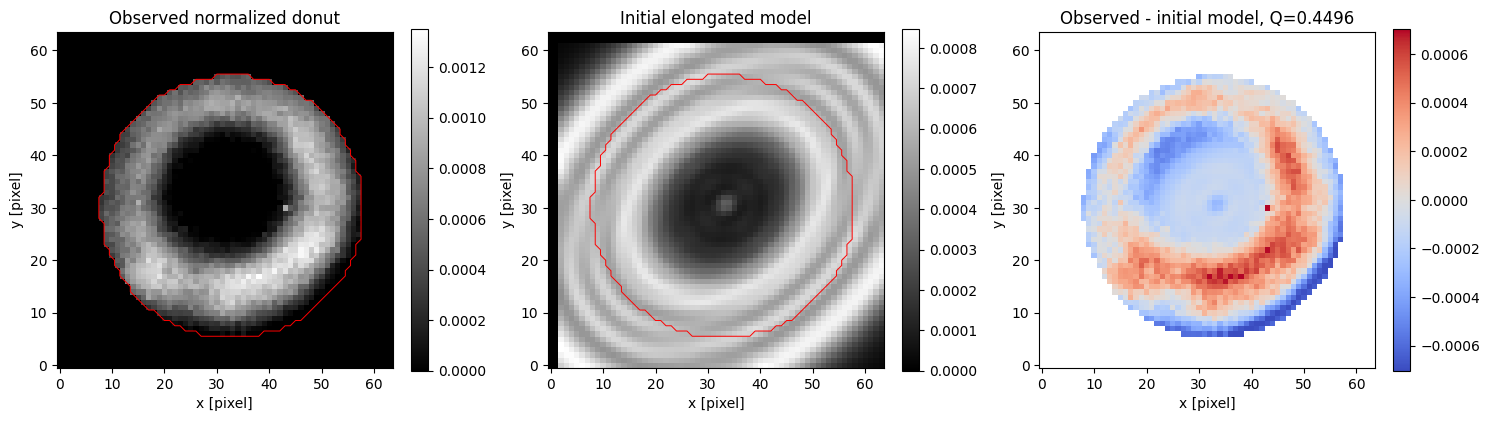

In [18]:
# ------------------------------------------------------------
# 12a. Initialize and display an intentionally elongated model
# ------------------------------------------------------------
# This is the model image used as the starting point for the iteration.
# We keep the moment-derived size/center estimate, but boost the astigmatism
# amplitude so the initial synthetic donut is visibly elongated.
initial_astig_amplitude = 4.0
moment_astig_norm = float(np.hypot(A5_pix, A6_pix))

if moment_astig_norm > 0:
    initial_a5 = initial_astig_amplitude * A5_pix / moment_astig_norm
    initial_a6 = initial_astig_amplitude * A6_pix / moment_astig_norm
else:
    initial_a5 = initial_astig_amplitude
    initial_a6 = 0.0

elongated_initial_params = clip_parameters(DonutParameters(
    seeing_fwhm_px=initial_params.seeing_fwhm_px,
    dx_px=initial_params.dx_px,
    dy_px=initial_params.dy_px,
    a4=initial_params.a4,
    a5=initial_a5,
    a6=initial_a6,
))

# From this point onward, the inverse loop starts from the elongated model.
initial_params = elongated_initial_params
initial_model, initial_wavefront = render_donut_model(
    initial_params,
    inverse_config,
    fit_mask,
    return_wavefront=True,
)
initial_residual = np.where(fit_mask, obs_norm - initial_model, np.nan)
initial_q = q_metric(obs_norm, initial_model, fit_mask)

print("----- Initial elongated model -----")
print(f"Initial Q      : {initial_q:.6f}")
for name, value in asdict(initial_params).items():
    print(f"{name:16s}: {value: .6f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

im0 = ax[0].imshow(obs_norm, origin="lower", cmap="gray")
ax[0].contour(fit_mask.astype(int), levels=[0.5], colors="red", linewidths=0.7)
ax[0].set_title("Observed normalized donut")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(initial_model, origin="lower", cmap="gray")
ax[1].contour(fit_mask.astype(int), levels=[0.5], colors="red", linewidths=0.7)
ax[1].set_title("Initial elongated model")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

res_limit = np.nanpercentile(np.abs(initial_residual), 99.0)
im2 = ax[2].imshow(
    initial_residual,
    origin="lower",
    cmap="coolwarm",
    vmin=-res_limit,
    vmax=res_limit,
)
ax[2].set_title(f"Observed - initial model, Q={initial_q:.4f}")
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for axis in ax:
    axis.set_xlabel("x [pixel]")
    axis.set_ylabel("y [pixel]")

fig.tight_layout()
plt.show()


----- Six-parameter DONUT inverse fit -----
Parameter units: seeing/dx/dy in detector pixels; a4-a6 in uncalibrated phase-amplitude model units
Initial parameters: {'seeing_fwhm_px': 2.0, 'dx_px': 1.3884193567728644, 'dy_px': -1.2328289845853853, 'a4': 19.8744173042573, 'a5': 3.9650575519602813, 'a6': 0.5275591053547825}
iter 00: Q 0.449612 -> 0.412070, rank 6, damping 0.700, params {'seeing_fwhm_px': 3.1627418524391517, 'dx_px': 0.4460837923529314, 'dy_px': -0.41432654220154463, 'a4': 19.470116653626757, 'a5': 2.9280560728298433, 'a6': 0.3071868894998392}
iter 01: Q 0.412070 -> 0.391814, rank 6, damping 0.700, params {'seeing_fwhm_px': 1.977711943522909, 'dx_px': -0.5951581935161773, 'dy_px': 0.8790437607858453, 'a4': 19.435386420025438, 'a5': 2.0614371085295025, 'a6': 0.21318583524083007}
iter 02: Q 0.391814 -> 0.389524, rank 6, damping 0.700, params {'seeing_fwhm_px': 2.4270842636239327, 'dx_px': -0.5535666173738525, 'dy_px': 0.9202939248421459, 'a4': 19.395434314609716, 'a5': 2.554

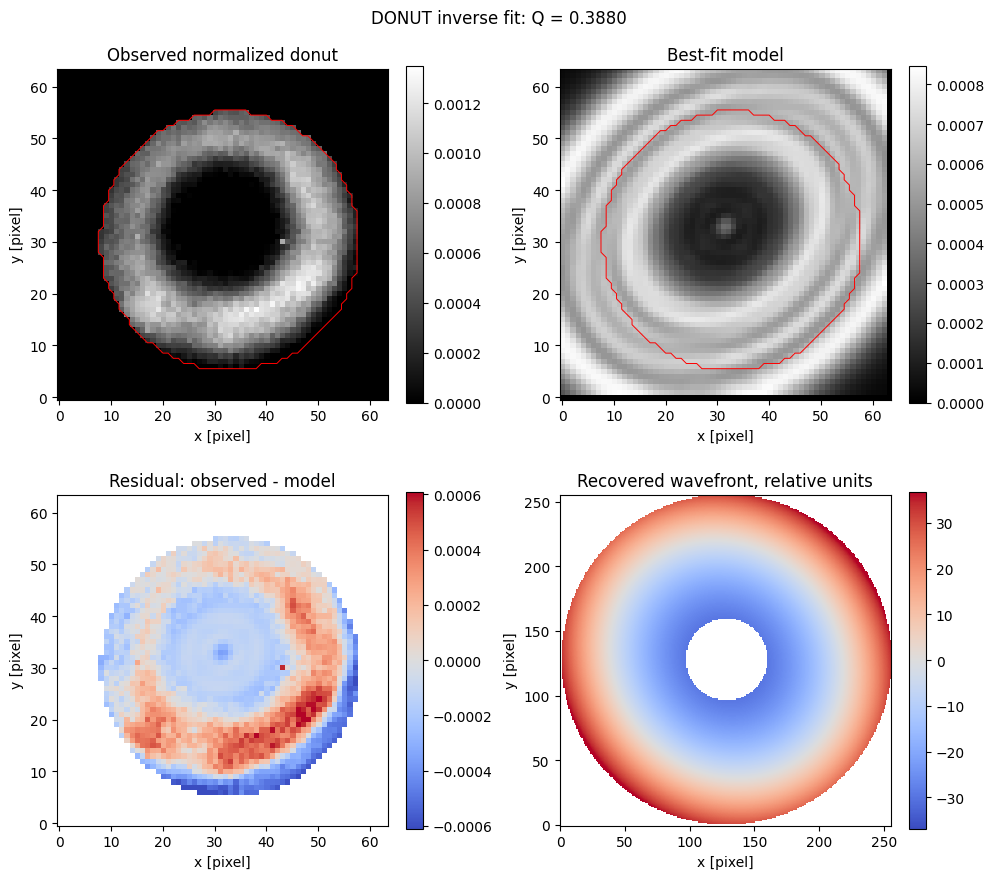

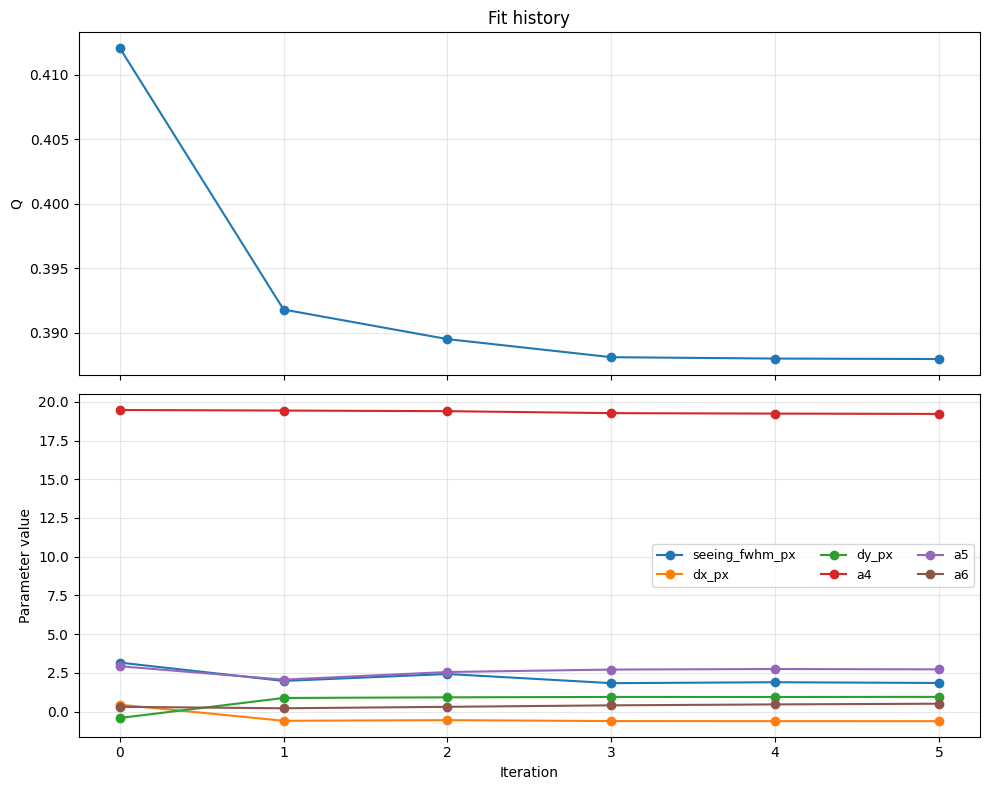

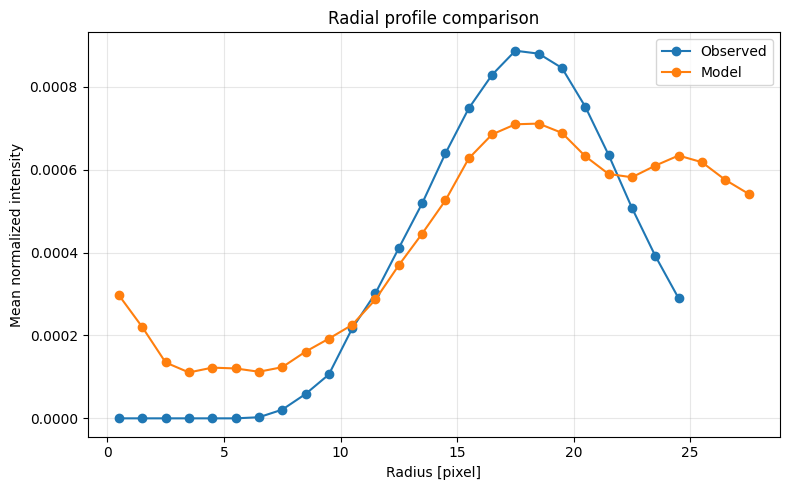


Saved inverse-fit products:
  processed/outputs/fits/candidate_x1597_y1687_model.fits
  processed/outputs/fits/candidate_x1597_y1687_residual.fits
  processed/outputs/fits/candidate_x1597_y1687_wavefront.fits
  processed/outputs/json/candidate_x1597_y1687_fit_result.json
  processed/outputs/tables/fit_summary.csv
  processed/outputs/figures/candidate_x1597_y1687_fit.png
  processed/outputs/figures/candidate_x1597_y1687_history.png
  processed/outputs/figures/candidate_x1597_y1687_profiles.png


In [19]:
# ------------------------------------------------------------
# 12b. Run inverse iterations and backtrack if Q increases
# ------------------------------------------------------------
params = clip_parameters(initial_params)
history = []
converged = False
stop_reason = "maximum iterations reached"

print("----- Six-parameter DONUT inverse fit -----")
print("Parameter units: seeing/dx/dy in detector pixels; a4-a6 in uncalibrated phase-amplitude model units")
print(f"Initial parameters: {asdict(params)}")

for iteration in range(inverse_config["max_iterations"]):
    model = render_donut_model(params, inverse_config, fit_mask)
    q_old = q_metric(obs_norm, model, fit_mask)

    delta, H, H_pinv, singular_values, effective_rank, condition_estimate = propose_svd_update(params, model)

    accepted = False
    best_candidate = params
    best_q = q_old
    accepted_damping = 0.0

    for damping in [
        inverse_config["damping"],
        inverse_config["damping"] / 2.0,
        inverse_config["damping"] / 4.0,
        inverse_config["damping"] / 8.0,
    ]:
        candidate = apply_delta(params, delta, damping)
        candidate_model = render_donut_model(candidate, inverse_config, fit_mask)
        candidate_q = q_metric(obs_norm, candidate_model, fit_mask)

        if np.isfinite(candidate_q) and candidate_q < best_q:
            best_candidate = candidate
            best_q = candidate_q
            accepted = True
            accepted_damping = damping
            break

    relative_improvement = (q_old - best_q) / max(q_old, 1.0e-12)

    history.append({
        "iteration": int(iteration),
        "q_start": float(q_old),
        "q_end": float(best_q),
        "relative_improvement": float(relative_improvement),
        "accepted": bool(accepted),
        "accepted_damping": float(accepted_damping),
        "effective_rank": int(effective_rank),
        "condition_estimate": float(condition_estimate),
        "singular_values": [float(value) for value in singular_values],
        "parameters": {key: float(value) for key, value in asdict(best_candidate).items()},
        "delta": {key: float(value) for key, value in zip(parameter_names, delta)},
    })

    print(
        f"iter {iteration:02d}: Q {q_old:.6f} -> {best_q:.6f}, "
        f"rank {effective_rank}, damping {accepted_damping:.3f}, "
        f"params {asdict(best_candidate)}"
    )

    params = best_candidate

    if not accepted:
        stop_reason = "no damping trial improved Q"
        break

    if relative_improvement < inverse_config["min_relative_improvement"]:
        converged = True
        stop_reason = "relative Q improvement below tolerance"
        break


best_params = params
best_model, best_wavefront = render_donut_model(
    best_params,
    inverse_config,
    fit_mask,
    return_wavefront=True,
)
residual_image = np.where(fit_mask, obs_norm - best_model, np.nan)
final_q = q_metric(obs_norm, best_model, fit_mask)

# Approximate unweighted uncertainty from Eq. (A5)-style pseudoinverse covariance.
# This ignores photon/read noise calibration and systematic model error.
final_H = finite_difference_jacobian(best_params, best_model)
final_H_pinv = np.linalg.pinv(final_H, rcond=inverse_config["svd_rcond"])
final_cov = final_H_pinv @ final_H_pinv.T
parameter_uncertainties = {
    name: float(np.sqrt(max(final_cov[i, i], 0.0)) * final_q)
    for i, name in enumerate(parameter_names)
}

print()
print("----- Fit result -----")
print(f"Converged: {converged}")
print(f"Stop reason: {stop_reason}")
print(f"Final Q: {final_q:.6f}")
for name, value in asdict(best_params).items():
    print(f"{name:16s}: {value: .6f} +/- {parameter_uncertainties[name]:.6f}")


# ------------------------------------------------------------
# Step 7. Diagnostics: images, history, radial profile
# ------------------------------------------------------------
output_root = Path("processed/outputs")
figures_dir = output_root / "figures"
fits_dir = output_root / "fits"
json_dir = output_root / "json"
tables_dir = output_root / "tables"
for directory in [figures_dir, fits_dir, json_dir, tables_dir]:
    directory.mkdir(parents=True, exist_ok=True)

candidate_stem = "candidate_x1597_y1687"
fit_figure_path = figures_dir / f"{candidate_stem}_fit.png"
history_figure_path = figures_dir / f"{candidate_stem}_history.png"
profile_figure_path = figures_dir / f"{candidate_stem}_profiles.png"
model_fits_path = fits_dir / f"{candidate_stem}_model.fits"
residual_fits_path = fits_dir / f"{candidate_stem}_residual.fits"
wavefront_fits_path = fits_dir / f"{candidate_stem}_wavefront.fits"
json_result_path = json_dir / f"{candidate_stem}_fit_result.json"
csv_summary_path = tables_dir / "fit_summary.csv"

fig, ax = plt.subplots(2, 2, figsize=(10, 9))

im0 = ax[0, 0].imshow(obs_norm, origin="lower", cmap="gray")
ax[0, 0].contour(fit_mask.astype(int), levels=[0.5], colors="red", linewidths=0.7)
ax[0, 0].set_title("Observed normalized donut")
plt.colorbar(im0, ax=ax[0, 0], fraction=0.046)

im1 = ax[0, 1].imshow(best_model, origin="lower", cmap="gray")
ax[0, 1].contour(fit_mask.astype(int), levels=[0.5], colors="red", linewidths=0.7)
ax[0, 1].set_title("Best-fit model")
plt.colorbar(im1, ax=ax[0, 1], fraction=0.046)

res_limit = np.nanpercentile(np.abs(residual_image), 99.0)
im2 = ax[1, 0].imshow(
    residual_image,
    origin="lower",
    cmap="coolwarm",
    vmin=-res_limit,
    vmax=res_limit,
)
ax[1, 0].set_title("Residual: observed - model")
plt.colorbar(im2, ax=ax[1, 0], fraction=0.046)

wave_limit = np.nanpercentile(np.abs(best_wavefront), 99.0)
im3 = ax[1, 1].imshow(
    best_wavefront,
    origin="lower",
    cmap="coolwarm",
    vmin=-wave_limit,
    vmax=wave_limit,
)
ax[1, 1].set_title("Recovered wavefront, relative units")
plt.colorbar(im3, ax=ax[1, 1], fraction=0.046)

for axis in ax.ravel():
    axis.set_xlabel("x [pixel]")
    axis.set_ylabel("y [pixel]")

fig.suptitle(f"DONUT inverse fit: Q = {final_q:.4f}")
fig.tight_layout()
fig.savefig(fit_figure_path, dpi=160)
plt.show()

history_q = [item["q_end"] for item in history]
history_params = {name: [item["parameters"][name] for item in history] for name in parameter_names}

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(range(len(history_q)), history_q, marker="o")
ax[0].set_ylabel("Q")
ax[0].set_title("Fit history")
ax[0].grid(True, alpha=0.3)

for name, values in history_params.items():
    ax[1].plot(range(len(values)), values, marker="o", label=name)
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Parameter value")
ax[1].grid(True, alpha=0.3)
ax[1].legend(ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig(history_figure_path, dpi=160)
plt.show()


def radial_profile(image, mask, x0, y0, max_radius=32):
    yy_profile, xx_profile = np.indices(image.shape)
    radius = np.hypot(xx_profile - x0, yy_profile - y0)
    bins = np.arange(0, max_radius + 1, 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    values = []

    for inner, outer in zip(bins[:-1], bins[1:]):
        annulus = mask & (radius >= inner) & (radius < outer) & np.isfinite(image)
        if annulus.any():
            values.append(float(np.mean(image[annulus])))
        else:
            values.append(np.nan)

    return centers, np.array(values)


model_center_x = detector_center_x + best_params.dx_px
model_center_y = detector_center_y + best_params.dy_px
r_centers, obs_profile = radial_profile(obs_norm, fit_mask, x_c, y_c)
_, model_profile = radial_profile(best_model, fit_mask, model_center_x, model_center_y)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_centers, obs_profile, marker="o", label="Observed")
ax.plot(r_centers, model_profile, marker="o", label="Model")
ax.set_xlabel("Radius [pixel]")
ax.set_ylabel("Mean normalized intensity")
ax.set_title("Radial profile comparison")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(profile_figure_path, dpi=160)
plt.show()


# ------------------------------------------------------------
# Step 8. Save derived products and machine-readable metadata
# ------------------------------------------------------------
fit_header = fits.Header()
fit_header["PROCSTAT"] = ("DONUT_FIT", "Derived inverse-fit product")
fit_header["QFINAL"] = (float(final_q), "Relative residual Q")
fit_header["CONVRGED"] = (bool(converged), "Convergence flag")
fit_header["UNITS"] = ("RELATIVE", "a4-a6 are uncalibrated model units")
for name, value in asdict(best_params).items():
    fit_header[name[:8].upper()] = float(value)

fits.writeto(model_fits_path, best_model.astype(np.float32), header=fit_header, overwrite=True)
fits.writeto(
    residual_fits_path,
    np.where(fit_mask, obs_norm - best_model, 0.0).astype(np.float32),
    header=fit_header,
    overwrite=True,
)
fits.writeto(wavefront_fits_path, best_wavefront.astype(np.float32), header=fit_header, overwrite=True)

source_metadata_path = Path("processed/crops/donut_candidate_x1597_y1687_metadata.json")
if source_metadata_path.exists():
    with open(source_metadata_path, "r", encoding="utf-8") as file:
        source_metadata = json.load(file)
else:
    source_metadata = {}

result = {
    "source": source_metadata,
    "preprocessing": {
        "background_adu": float(background_adu) if "background_adu" in globals() else None,
        "background_rms_adu": float(background_std_adu) if "background_std_adu" in globals() else None,
        "fit_pixels": int(fit_mask.sum()),
        "normalized_flux_inside_mask": float(obs_norm[fit_mask].sum()),
    },
    "instrument_assumptions": {
        "central_obscuration_ratio": inverse_config["central_obscuration_ratio"],
        "fft_grid_size": inverse_config["fft_grid_size"],
        "image_plane_window_fft_px": inverse_config["image_plane_window_fft_px"],
        "calibration_status": "uncalibrated; coefficients are relative phase-amplitude model units",
    },
    "fit": {
        "converged": bool(converged),
        "stop_reason": stop_reason,
        "iterations": len(history),
        "final_q": float(final_q),
        "parameter_units": {
            "seeing_fwhm_px": "detector pixels",
            "dx_px": "detector pixels",
            "dy_px": "detector pixels",
            "a4": "uncalibrated phase-amplitude model units",
            "a5": "uncalibrated phase-amplitude model units",
            "a6": "uncalibrated phase-amplitude model units",
        },
        "parameters": {key: float(value) for key, value in asdict(best_params).items()},
        "parameter_uncertainties": parameter_uncertainties,
        "bounds": parameter_bounds,
        "finite_difference_steps": parameter_steps,
        "svd_rcond": inverse_config["svd_rcond"],
        "singular_values_last_iteration": history[-1]["singular_values"] if history else [],
        "effective_rank_last_iteration": history[-1]["effective_rank"] if history else None,
        "history": history,
    },
    "outputs": {
        "model_fits": str(model_fits_path),
        "residual_fits": str(residual_fits_path),
        "wavefront_fits": str(wavefront_fits_path),
        "fit_figure": str(fit_figure_path),
        "history_figure": str(history_figure_path),
        "profile_figure": str(profile_figure_path),
        "summary_csv": str(csv_summary_path),
    },
    "warnings": [
        "Prototype cell has not yet passed the required synthetic inverse validation suite.",
        "Central obstruction ratio and FFT-to-detector scale are assumptions.",
        "Do not interpret a4-a6 as micrometre rms wavefront coefficients.",
        "Residual structure must be inspected before treating the real-data fit as scientifically credible.",
    ],
}

with open(json_result_path, "w", encoding="utf-8") as file:
    json.dump(result, file, indent=2)

summary_row = {
    "candidate": candidate_stem,
    "converged": converged,
    "iterations": len(history),
    "final_q": final_q,
    **{name: getattr(best_params, name) for name in parameter_names},
}

with open(csv_summary_path, "w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=list(summary_row.keys()))
    writer.writeheader()
    writer.writerow(summary_row)

print()
print("Saved inverse-fit products:")
print(f"  {model_fits_path}")
print(f"  {residual_fits_path}")
print(f"  {wavefront_fits_path}")
print(f"  {json_result_path}")
print(f"  {csv_summary_path}")
print(f"  {fit_figure_path}")
print(f"  {history_figure_path}")
print(f"  {profile_figure_path}")
